In [ ]:
!unzip split_data.zip -d dataset


Archive:  split_data.zip
   creating: dataset/split_data/
   creating: dataset/split_data/test/
   creating: dataset/split_data/test/anger/
  inflating: dataset/split_data/test/anger/g2818sb7780bmkdapg.jpg  
  inflating: dataset/split_data/test/anger/g8a4mw16bnr9o25oqd.jpg  
  inflating: dataset/split_data/test/anger/ganhrce2edip06w7an.jpg  
  inflating: dataset/split_data/test/anger/GBP-scam.jpg  
  inflating: dataset/split_data/test/anger/gi0venvjw7zp0x7g27.jpg  
  inflating: dataset/split_data/test/anger/gmpjvx38elyg0cye0d.jpg  
  inflating: dataset/split_data/test/anger/godupdates-lady-got-rude-with-a-Starbucks-barista-apology-letter-fb.jpg  
  inflating: dataset/split_data/test/anger/gog1i3qqqj2cm5jiuc.jpg  
  inflating: dataset/split_data/test/anger/gr0n9z2if2cr0v5rch.jpg  
  inflating: dataset/split_data/test/anger/grdh6brx51v3xinvrb.jpg  
  inflating: dataset/split_data/test/anger/grumpy-senior-man.jpg  
  inflating: dataset/split_data/test/anger/gthmpih8udn51ec8eo.jpg  
  infl

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dir = '/content/split_data/train'
test_dir = '/content/split_data/test'

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

In [ ]:
test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

In [ ]:
class_names = train_dataset.classes
print(f"Найдено классов: {len(class_names)}")
print(f"Классы: {class_names}")

Найдено классов: 6
Классы: ['anger', 'disgust', 'fear', 'happy', 'pain', 'sad']


In [ ]:
if train_dataset.classes != test_dataset.classes:
    print("ВНИМАНИЕ: классы в train и test не совпадают!")
else:
    print("Классы в train и test совпадают")

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

Классы в train и test совпадают
Размер обучающей выборки: 958
Размер тестовой выборки: 240


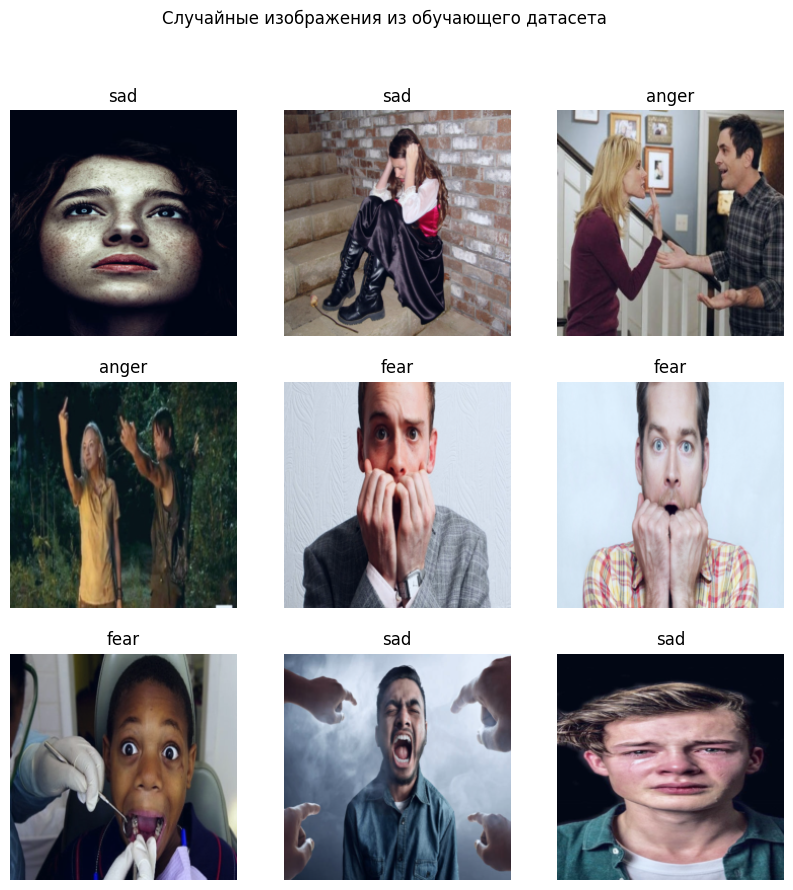

In [ ]:
import random
import matplotlib.pyplot as plt

def show_random_images(dataset, class_names, num_images=9):

    plt.figure(figsize=(10,10))

    for i in range(num_images):

        idx = random.randint(0, len(dataset)-1)

        image, label = dataset[idx]

        img = image.permute(1, 2, 0).numpy()

        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(class_names[label])
        plt.axis("off")

    plt.suptitle("Случайные изображения из обучающего датасета")
    plt.show()


show_random_images(train_dataset, class_names)

In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
from torchvision import models
import torch

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


In [ ]:
if hasattr(model, "fc"):

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(class_names))

elif hasattr(model, "classifier"):

    if isinstance(model.classifier, nn.Sequential):
        num_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(num_features, len(class_names))
    else:
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, len(class_names))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
model = model.to(device)

Используемое устройство: cuda


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

Epoch 5/5
Train Loss: 0.0217
Val Loss: 0.7553
Val Accuracy: 73.33%


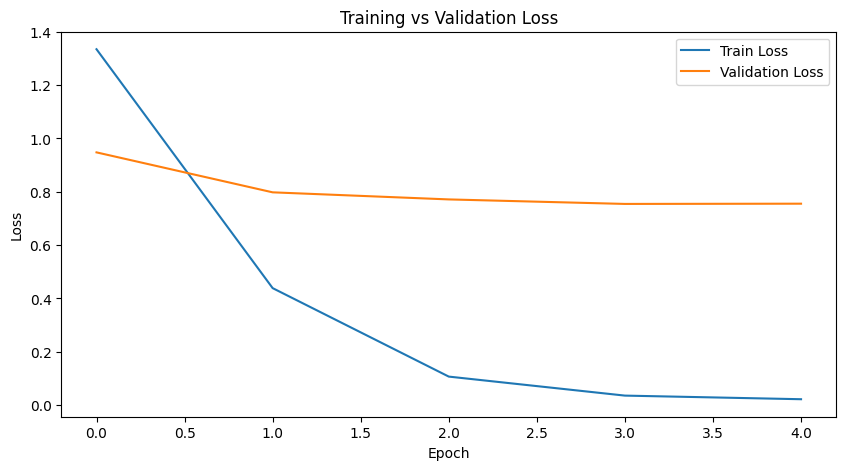

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from IPython.display import clear_output

train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(test_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    clear_output(wait=True)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_accuracy:.2f}%")

    plt.figure(figsize=(10,5))

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title("Training vs Validation Loss")

    plt.legend()

    plt.show()

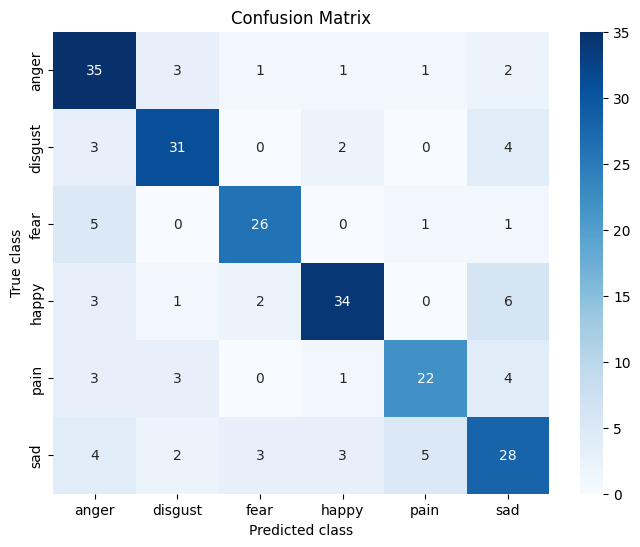

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.title("Confusion Matrix")

plt.show()

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

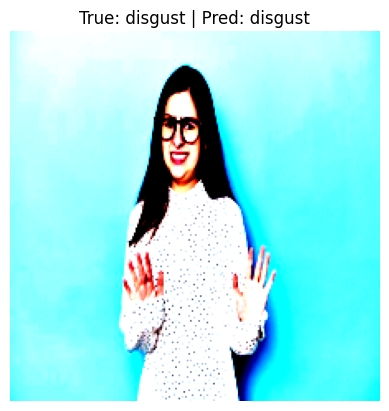

In [ ]:
import random

img, label = test_dataset[random.randint(0, len(test_dataset)-1)]

model.eval()

with torch.no_grad():

    input_tensor = img.unsqueeze(0).to(device)

    output = model(input_tensor)

    _, predicted = torch.max(output, 1)

plt.imshow(img.permute(1,2,0))
plt.title(f"True: {class_names[label]} | Pred: {class_names[predicted.item()]}")
plt.axis("off")

Модель переобучена что видно из низкого train loss и высокого validation loss, заморозим все слои кроме "головы".

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, len(class_names))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False


for param in model.layer4.parameters():
    param.requires_grad = True


for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

Используемое устройство: cuda


In [ ]:
finetune_epochs = 3

for epoch in range(finetune_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"FineTune Epoch {epoch+1}/{finetune_epochs} | Loss: {running_loss:.4f}")

FineTune Epoch 1/3 | Loss: 39.1135
FineTune Epoch 2/3 | Loss: 14.2682
FineTune Epoch 3/3 | Loss: 4.1154


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 77.50%


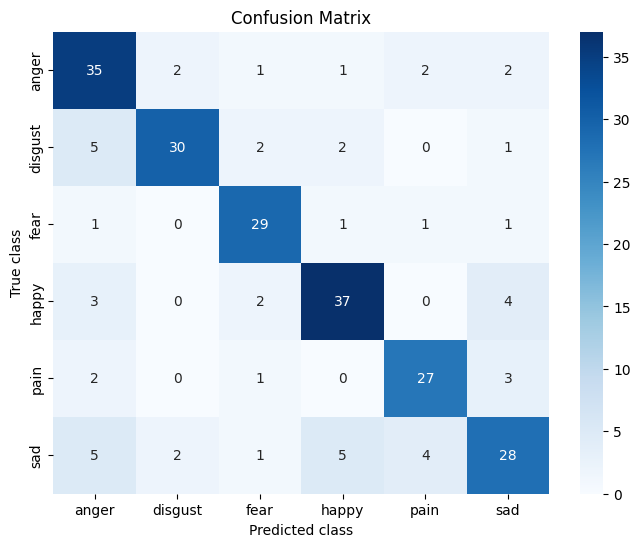

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Строим confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.title("Confusion Matrix")

plt.show()

Второй моделью попробуем обучить Densenet, т.к. она устойчива к переобучению

In [ ]:
model2 = models.densenet121(weights='IMAGENET1K_V1')

for param in model2.parameters():
    param.requires_grad = False

if hasattr(model2, "fc"):

    num_features = model2.fc.in_features
    model2.fc = nn.Linear(num_features, len(class_names))

elif hasattr(model, "classifier"):

    if isinstance(model2.classifier, nn.Sequential):
        num_features = model2.classifier[-1].in_features
        model2.classifier[-1] = nn.Linear(num_features, len(class_names))
    else:
        num_features = model2.classifier.in_features
        model2.classifier = nn.Linear(num_features, len(class_names))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
model = model.to(device)

Используемое устройство: cuda


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-6
)

In [ ]:
finetune_epochs = 3

for epoch in range(finetune_epochs):

    model2.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"FineTune Epoch {epoch+1}/{finetune_epochs} | Loss: {running_loss:.4f}")

FineTune Epoch 1/3 | Loss: 0.1221
FineTune Epoch 2/3 | Loss: 0.1114
FineTune Epoch 3/3 | Loss: 0.1025


In [ ]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 74.58%


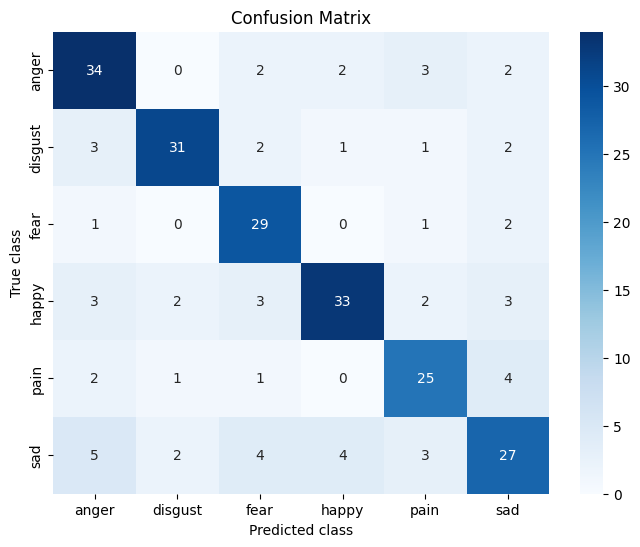

In [ ]:
model2.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Строим confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.title("Confusion Matrix")

plt.show()

ResNet показал себя немного лучше, посмотрим ее визуализации

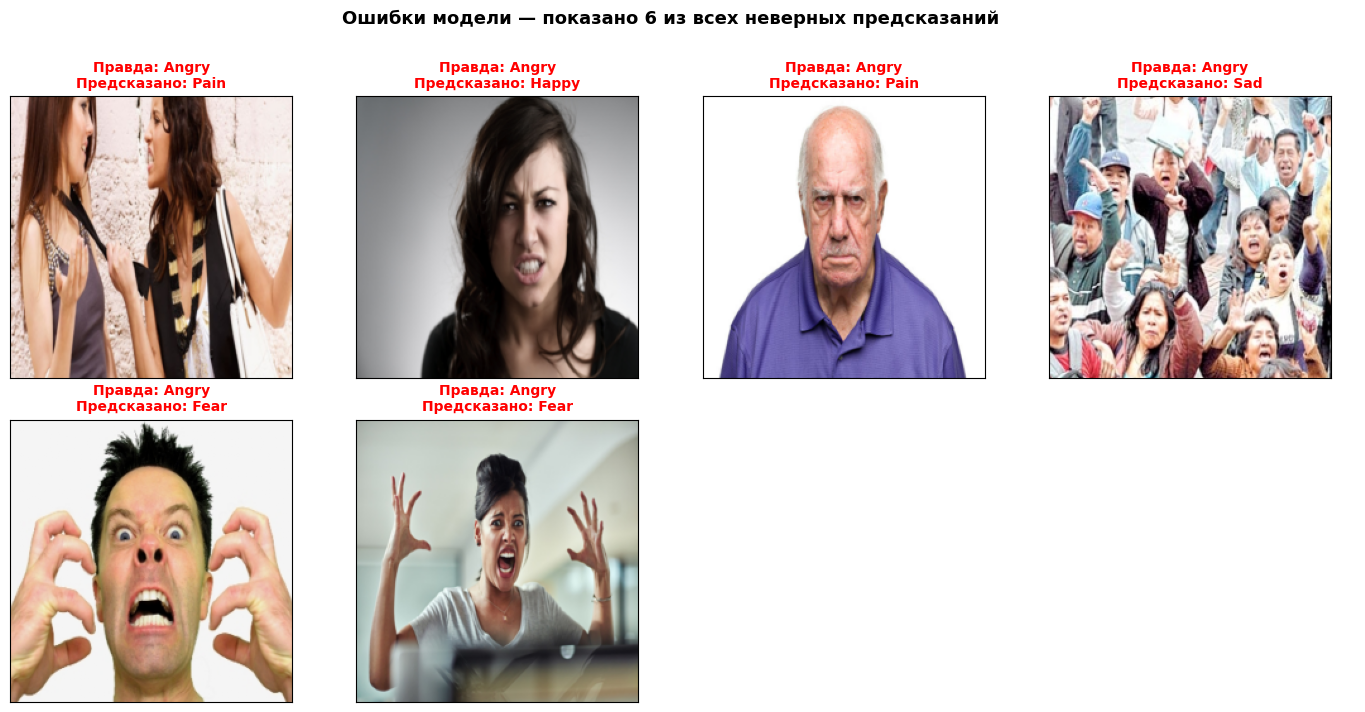

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def show_errors(model, dataloader, class_names, device, max_errors=16):
    """
    Показывает примеры где модель ошиблась.

    Args:
        model       — обученная модель
        dataloader  — test_loader
        class_names — список имён классов ['Angry', 'Disgust', ...]
        device      — cuda / cpu
        max_errors  — сколько ошибок показать (макс 16)
    """
    model.eval()

    error_images  = []
    error_preds   = []
    error_labels  = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs   = model(images)
            _, predicted = torch.max(outputs, 1)

            # Находим индексы где модель ошиблась
            wrong_mask = predicted != labels

            error_images.append(images[wrong_mask].cpu())
            error_preds.append(predicted[wrong_mask].cpu())
            error_labels.append(labels[wrong_mask].cpu())

            # Останавливаемся когда набрали достаточно
            total_errors = sum(len(e) for e in error_images)
            if total_errors >= max_errors:
                break

    # Собираем всё в один тензор
    error_images = torch.cat(error_images)[:max_errors]
    error_preds  = torch.cat(error_preds)[:max_errors]
    error_labels = torch.cat(error_labels)[:max_errors]

    n = len(error_images)
    if n == 0:
        print("Ошибок не найдено — модель всё предсказала верно!")
        return

    # ── Денормализация для отображения ──────────────────────────────────────
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def denormalize(img_tensor):
        return (img_tensor * std + mean).clamp(0, 1)

    # ── Сетка изображений ───────────────────────────────────────────────────
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        ax = axes[i]

        if i < n:
            img = denormalize(error_images[i]).permute(1, 2, 0).numpy()

            true_label = class_names[error_labels[i]]
            pred_label = class_names[error_preds[i]]

            ax.imshow(img)
            ax.set_title(
                f"Правда: {true_label}\nПредсказано: {pred_label}",
                fontsize=10,
                color='red',
                fontweight='bold'
            )
        else:
            ax.axis('off')  # пустые ячейки в конце сетки

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"Ошибки модели — показано {n} из всех неверных предсказаний",
        fontsize=13,
        fontweight='bold',
        y=1.01
    )

    plt.tight_layout()
    plt.show()


# ── Использование ────────────────────────────────────────────────────────────
emotion_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Pain', 'Sad']

show_errors(
    model      = model,
    dataloader = test_loader,
    class_names= emotion_names,
    device     = device,
    max_errors = 6
)

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=cfb603f9e1ff5e1425f24d5381530f943ab679b6e6e77caab9f4f6b636ba8a9f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
)

In [ ]:
def show_gradcam(image_tensor):

    model.eval()

    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax().item()

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    # переводим tensor в numpy
    img = image_tensor.permute(1,2,0).numpy()

    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,6))
    plt.imshow(visualization)
    plt.title(f"Predicted class: {class_names[pred_class]}")
    plt.axis("off")

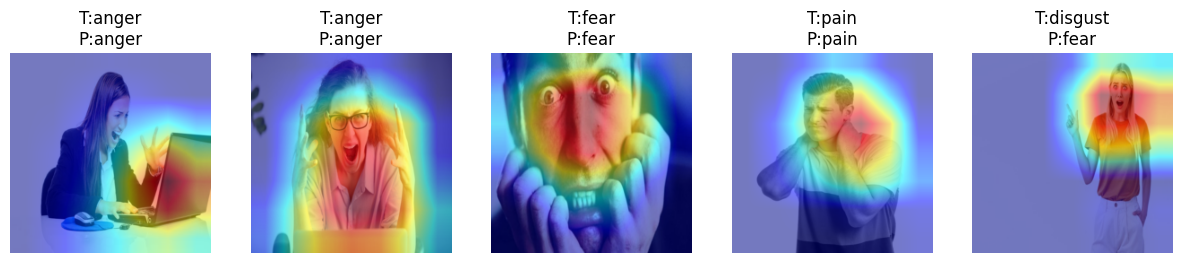

In [ ]:
import random

num_examples = 5

plt.figure(figsize=(15,5))

for i in range(num_examples):

    img, label = test_dataset[random.randint(0, len(test_dataset)-1)]

    plt.subplot(1, num_examples, i+1)

    model.eval()

    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax().item()

    targets = [ClassifierOutputTarget(pred)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    image_np = img.permute(1,2,0).numpy()
    image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())

    visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.title(f"T:{class_names[label]}\nP:{class_names[pred]}")
    plt.axis("off")

plt.show()

In [ ]:
layers = {
    "Early features": model.conv1,
    "Middle features": model.layer2,
    "Deep features": model.layer4
}

In [ ]:
feature_maps = {}

def get_features(name):

    def hook(model, input, output):
        feature_maps[name] = output.detach()

    return hook


hooks = []

for name, layer in layers.items():
    hooks.append(layer.register_forward_hook(get_features(name)))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

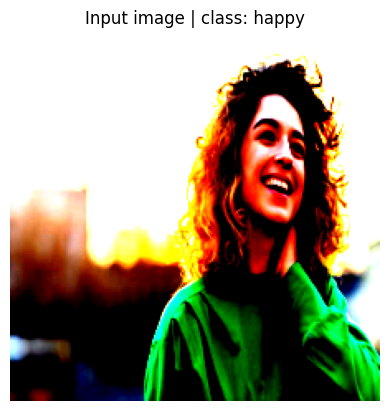

In [ ]:
import random

img, label = test_dataset[random.randint(0, len(test_dataset)-1)]

input_tensor = img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    model(input_tensor)

plt.imshow(img.permute(1,2,0))
plt.title(f"Input image | class: {class_names[label]}")
plt.axis("off")

In [ ]:
def visualize_feature_maps(feature_map, title, max_maps=16):

    feature_map = feature_map.squeeze(0)

    num_maps = min(max_maps, feature_map.shape[0])

    plt.figure(figsize=(12,6))

    for i in range(num_maps):

        plt.subplot(4,4,i+1)

        plt.imshow(feature_map[i].cpu(), cmap="viridis")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

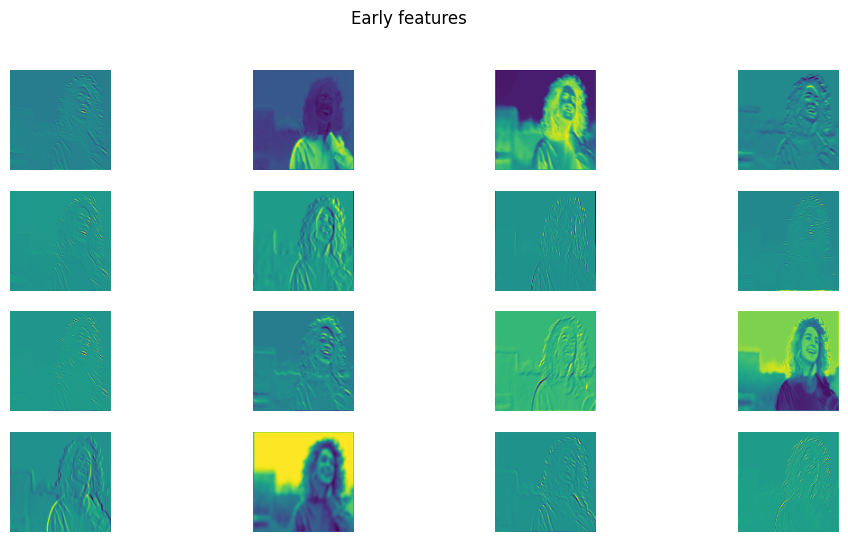

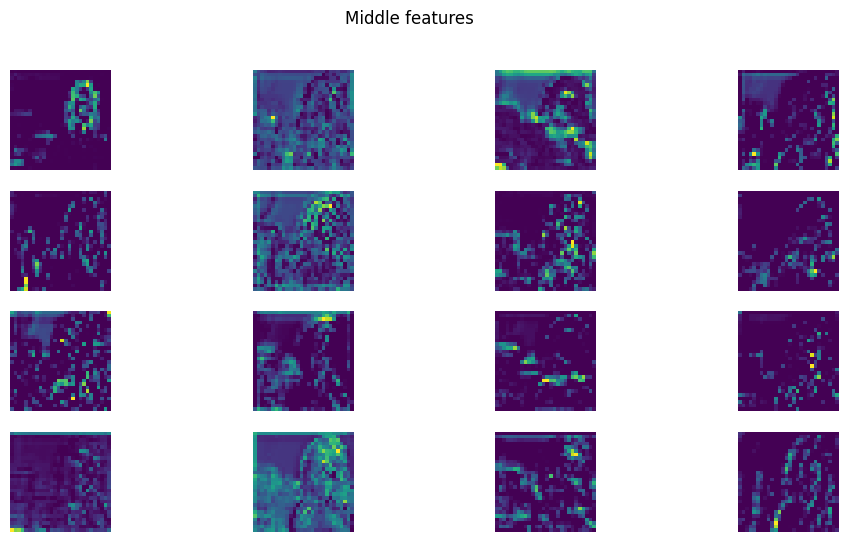

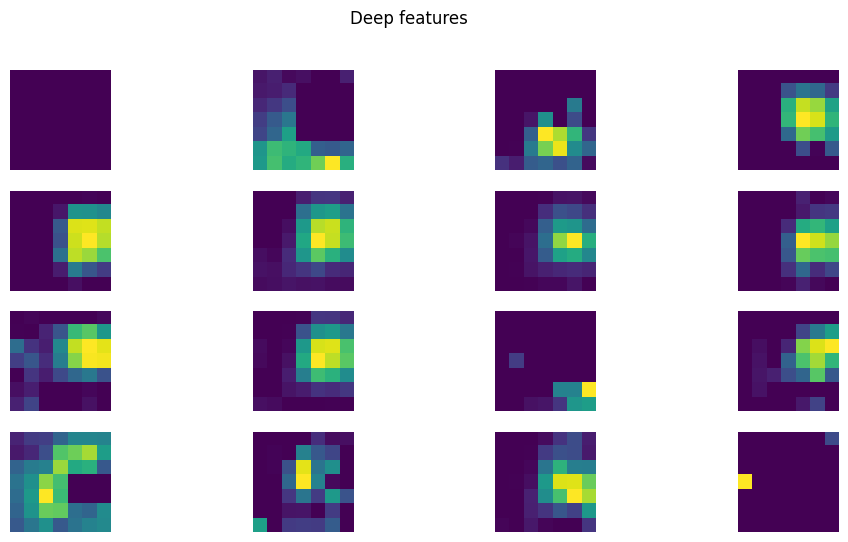

In [ ]:
for name in feature_maps:

    visualize_feature_maps(
        feature_maps[name],
        title=name
    )